In [ ]:
# ==========================================
# Transfer Learning with MobileNetV2
# Oxford-IIIT Pets Dataset
# Prediction using USER UPLOADED IMAGE
# ==========================================

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import cv2
import gc

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from google.colab import files

# --------- Clear memory ---------
tf.keras.backend.clear_session()
gc.collect()

# --------- Load Dataset (only for training) ---------
(ds_train, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes
IMG_SIZE = 128
BATCH_SIZE = 16

# --------- Preprocessing function ---------
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label

train_ds = ds_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --------- Load MobileNetV2 (Pretrained) ---------
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False   # Freeze feature extractor

# --------- Add Classification Head ---------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# --------- Compile ---------
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --------- Train Model ---------
model.fit(train_ds, epochs=3)

# --------- Evaluate (optional) ---------
loss, acc = model.evaluate(test_ds)
print("Validation Accuracy:", acc)



Epoch 1/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 50s 243ms/step - accuracy: 0.4198 - loss: 2.2512
Epoch 2/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 44s 237ms/step - accuracy: 0.8766 - loss: 0.3831
Epoch 3/3
184/184 ━━━━━━━━━━━━━━━━━━━━ 43s 234ms/step - accuracy: 0.9566 - loss: 0.1668
46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 239ms/step - accuracy: 0.8558 - loss: 0.5025
Validation Accuracy: 0.8491848111152649


Saving dog-lab.webp to dog-lab.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


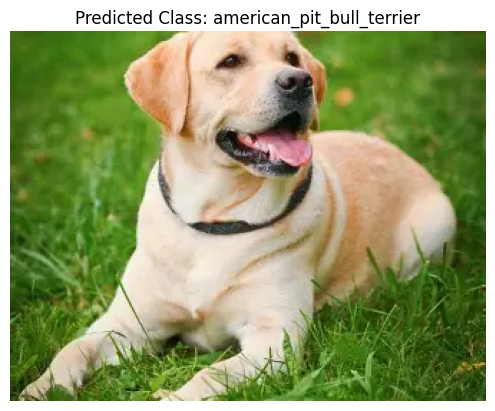

In [ ]:
# ==================================================
# --------- UPLOAD YOUR OWN IMAGE & PREDICT ---------
# ==================================================

uploaded = files.upload()

for file_name in uploaded.keys():
    img = cv2.imread(file_name)

# Convert BGR → RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize & preprocess
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_processed = preprocess_input(img_resized.astype("float32"))

# Reshape for model
img_input = np.expand_dims(img_processed, axis=0)

# Predict
prediction = model.predict(img_input)
predicted_class = np.argmax(prediction)

class_name = ds_info.features["label"].int2str(predicted_class)

# Display result
plt.imshow(img)
plt.title(f"Predicted Class: {class_name}")
plt.axis("off")
plt.show()
